# 06 · Does a 2017 model work on 2018?

**Question.** Trained on all of CIC-IDS2017, does a detector work on CSE-CIC-IDS2018, recorded a
year later on a different network with the same flow tool? This is forward in time and on a new
network at once.

Thresholds are frozen on a 20% holdout of 2017 benign traffic. The actual false positive rate on
2018 shows how far normal traffic moved.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"
summary = load_summary()

def finding(folds, labels=None, caveats=None):
    for f in folds:
        d = summary["folds"][f]
        quotable = {n: v["budgets"]["0.01"]["recall"]["median"]
                    for n, v in d["detectors"].items() if not v["budget_violated"]["0.01"]}
        broke = [NAMES[n] for n, v in d["detectors"].items() if v["budget_violated"]["0.01"]]
        # ties go to the single model (a hybrid that gave one model the whole budget is that model)
        best = max(quotable, key=lambda n: (quotable[n], "+" not in n)) if quotable else None
        line = f"{(labels or {}).get(f, f)}: "
        if d["unseen_test_families"]:
            line += f"unseen families {', '.join(d['unseen_test_families'])}. "
        line += (f"Best detector within its false-alarm budget: {NAMES[best]}, recall {quotable[best]:.1%} "
                 f"(median of {len(d['seeds'])} seeds)" if best else "No detector stayed within its false-alarm budget")
        if broke:
            line += f". Over budget (recall not quotable): {', '.join(broke)}"
        if best and d["detectors"][best].get("shortcut_flag"):
            line += f". Shortcut flag: one feature ({', '.join(d['best_single_feature'])}) comes within 0.05 AP of it"
        if (caveats or {}).get(f):
            line += f". CAVEAT: {caveats[f]}"
        print(line + ".")

finding(["2017_to_2018"], {"2017_to_2018": "Train all 2017, test all 2018"})


Train all 2017, test all 2018: Best detector within its false-alarm budget: Logistic regression, recall 13.0% (median of 5 seeds). Over budget (recall not quotable): Autoencoder, LightGBM, Hybrid: LightGBM + anomaly model.


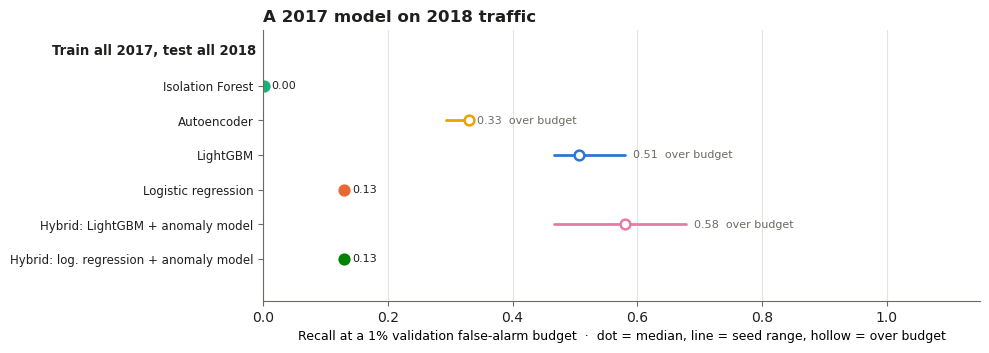

,fold,question,detector,recall (median),recall range,actual FPR range,AP (median),prevalence
0,2017_to_2018,"new network, one year later",Isolation Forest,0.001,0.000-0.001,0.0009-0.0012,0.156,0.1702
1,2017_to_2018,"new network, one year later",Autoencoder,0.330,0.293-0.331,0.1622-0.2261,0.192,0.1702
2,2017_to_2018,"new network, one year later",LightGBM,0.507,0.467-0.581,0.0249-0.0587,0.671,0.1702
3,2017_to_2018,"new network, one year later",Logistic regression,0.130,0.130-0.131,0.0077-0.0081,0.526,0.1702
4,2017_to_2018,"new network, one year later",Hybrid: LightGBM + anomaly model,0.581,0.467-0.679,0.0249-0.1819,NaN,0.1702
5,2017_to_2018,"new network, one year later",Hybrid: log. regression + anomaly model,0.130,0.130-0.131,0.0077-0.0081,NaN,0.1702


In [2]:
FOLDS = ['2017_to_2018']
LABELS = {'2017_to_2018': 'Train all 2017, test all 2018'}
fig = recall_dots(summary, FOLDS, 'A 2017 model on 2018 traffic', LABELS)
plt.show()
recall_table(summary, FOLDS)

In [3]:
# Recall per attack family at the 1% budget (median over seeds, n = flows in the test set)
rows = {}
for f in FOLDS:
    fold = summary["folds"][f]
    for det, d in fold["detectors"].items():
        for fam, r in d["per_family_recall_at_1pct"].items():
            rows.setdefault((LABELS[f], fam), {})[NAMES[det]] = round(r["median"], 3)
pd.DataFrame(rows).T

Isolation Forest  Autoencoder  LightGBM  Logistic regression  Hybrid: LightGBM + anomaly model  Hybrid: log. regression + anomaly model
Train all 2017, test all 2018 Bot                               0.000        0.501     0.000                0.000                             0.011                                    0.000
                              Brute force (FTP/SSH)             0.000        0.000     0.993                0.508                             0.993                                    0.508
                              DDoS                              0.000        0.556     0.286                0.002                             0.445                                    0.002
                              DoS                               0.004        0.034     0.951                0.234                             0.951                                    0.234
                              Infiltration                      0.001        0.232     0.186                0.055                             0.197                                    0.055
                              Web attack                        0.000        0.616     0.510                0.000                             0.541                                    0.000

## Why it fails: the same column, measured differently

The flow tool changed between the two captures. Single-packet DNS queries are the same kind of
flow in both years, so their header-length features should match. They do not:

In [4]:
cols = ["Destination Port", "Total Fwd Packets", "Fwd Header Length", "min_seg_size_forward", "Has_Init_Win_fwd", "Label"]
rows = {}
for year in ["2017", "2018"]:
    d = pd.read_parquet(f"../data/processed/cicids{year}_eval.parquet", columns=cols)
    dns = d[(d["Label"] == "BENIGN") & (d["Destination Port"] == 53) & (d["Total Fwd Packets"] == 1)]
    rows[year] = {"single-packet DNS flows": len(dns),
                  "share with a TCP window": round(dns["Has_Init_Win_fwd"].mean(), 3),
                  "Fwd Header Length (top values)": dns["Fwd Header Length"].value_counts(normalize=True).head(3).round(3).to_dict(),
                  "min_seg_size_forward (top values)": dns["min_seg_size_forward"].value_counts(normalize=True).head(3).round(3).to_dict()}
pd.DataFrame(rows)

,2017,2018
single-packet DNS flows,256225,331783
share with a TCP window,0.0,0.0
Fwd Header Length (top values),"{32: 0.481, 20: 0.452, 40: 0.055}","{8: 1.0, 24: 0.0, 20: 0.0}"
min_seg_size_forward (top values),"{32: 0.481, 20: 0.452, 40: 0.055}","{8: 1.0, 24: 0.0, 20: 0.0}"


## What this shows

- **Within budget, only logistic regression is quotable, and it catches little.** LightGBM ranks
  2018 traffic better (higher AP) and catches DoS and brute force well, but its frozen threshold
  lets through 2.5-5.9% of 2018 benign flows: normal traffic moved between the two networks.
- **The flow tool changed what columns mean.** Single-packet DNS queries carry an 8-byte forward
  header in 2018 (the true UDP header size) and 20-40 bytes in 2017. Same column name, different
  measurement. `min_seg_size_forward` is also the single most separating feature on this fold.
- **Attack names hide different behaviour.** The archived diagnostics
  (`notebooks/archive/cross_year_diagnostics.ipynb`) show, for example, 2018 SSH brute-force flows
  about 32 times shorter than 2017's, and 2018 DoS Hulk flows with no reply packets.

## What would fix it

Not a model change. The data needs consistent feature extraction across captures (one flow tool
version, validated by checks like the DNS test above), and thresholds need recalibrating on recent
benign traffic from the network being monitored.

## Limits

Both datasets come from the same lab and flow tool, so this is a mild test of transfer. A dataset
from a different tool would need retraining on a different feature set.